# Mejora del método de estimación del Polo Norte Galáctico (NGP)
### Datos reales de Gaia DR3, métodos clásicos revisados, y un estimador de círculo máximo sin parámetros libres

**Autor de la propuesta original**: L. Cano (2022), *Approximation.ipynb*, `automatedAR.py`, `automatedDEC.py`, `DEC2.py`.
**Este notebook**: análisis independiente ("clean-room"), construido con datos reales de Gaia DR3 y una
batería de módulos propios (`gaia_fetcher.py`, `ngp_classic.py`, `ngp_3d.py`, `param_sweep.py`,
`bootstrap.py`, `report.py`). No se modifica ni se importa ningún archivo del autor original.

Este notebook se ejecuta de principio a fin sin conexión a internet (usa el catálogo cacheado
`data/gaia_disk_stars.csv`, 53,082 estrellas reales de Gaia DR3).


## 1. Introducción

El trabajo original de L. Cano (2022) propone tres métodos geométricos sencillos para estimar la
posición del **Polo Norte Galáctico (NGP)** a partir de estrellas del disco galáctico observadas
desde el Sol:

1. **`aprox_ar`** — un método de "simetría de pares": agrupa estrellas por declinación y usa la
   simetría de sus ascensiones rectas (AR) alrededor de un valor de referencia (`ar_ref`) para
   estimar la AR del NGP.
2. **`aprox_dec1`** — usa las *n* estrellas con mayor |declinación| para estimar la declinación
   del NGP (δ ≈ 90° − |δ_estrella|).
3. **`aprox_dec2`** — repite la idea de `aprox_dec1` pero restringida a una ventana angular en AR
   alrededor del NGP estimado.

Estos métodos son elegantes y didácticos, pero tienen dos limitaciones importantes que este
notebook busca abordar:

- **Datos**: el análisis original se apoyaba en catálogos más pequeños / menos homogéneos que los
  actualmente disponibles en **Gaia DR3**. Aquí usamos una muestra real y reproducible de
  53,082 estrellas del disco (filtros: `parallax > 0`, `parallax_over_error > 5`, `|b| < 15°`,
  `G < 15`).
- **Método sin parámetros libres**: `aprox_ar` requiere un valor de referencia `ar_ref` —el
  propio NGP teórico— como *prior*, lo cual introduce una circularidad metodológica (se necesita
  conocer aproximadamente la respuesta para poder buscarla). Este notebook presenta un estimador
  alternativo, el **ajuste de círculo máximo por SVD** (`great_circle_pole`), que no requiere
  ningún parámetro ni conocimiento previo del NGP.
- **Estadística formal**: se añade *bootstrap* (remuestreo con reemplazo) para reportar
  intervalos de confianza del 95%, y un barrido sistemático de los parámetros libres de cada
  método (`param_sweep.py`) para cuantificar su sensibilidad.

**Resultado adelantado**: contrario a la propuesta inicial de este proyecto de mejora (usar
distancias 3D vía RANSAC), los datos reales muestran que el **ajuste de círculo máximo sin
distancia** es el mejor estimador — la distancia (1/paralaje) introduce más ruido del que aporta
información. Este hallazgo, guiado por los datos, es la contribución central de este notebook.


## 2. Datos Gaia DR3

Cargamos el catálogo cacheado (sin red) y describimos su contenido.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from gaia_fetcher import fetch_gaia_stars

data = fetch_gaia_stars()  # lee data/gaia_disk_stars.csv (cache, sin red)
print(f"Estrellas cargadas: {len(data)}")
data.describe()


Estrellas cargadas: 53082


,ra,dec,parallax,parallax_error,pmra,pmdec,phot_g_mean_mag,l,b
count,53082.000000,53082.000000,53082.000000,53082.000000,53082.000000,53082.000000,53082.000000,53082.000000,53082.000000
mean,207.291380,-10.785955,0.871947,0.023675,-2.446247,-2.635417,13.801561,189.398275,-0.781309
std,89.406515,41.093215,1.150410,0.026501,8.141184,9.277742,1.117876,116.622576,7.557051
min,0.002124,-77.735744,0.067315,0.007971,-317.526130,-565.336300,3.023800,0.000604,-14.999135
25%,122.161061,-48.202558,0.331425,0.015638,-5.084657,-5.200336,13.312979,74.327717,-6.588912
50%,235.390776,-18.257729,0.603713,0.019446,-2.083195,-2.225893,14.121567,207.231139,-1.407231
75%,281.768351,25.441956,1.033647,0.024601,0.317042,0.765101,14.628811,299.190924,4.995304
max,359.986307,77.835721,69.007547,0.908113,264.016994,340.639839,14.999971,359.996506,14.999425


**Filtros aplicados en la consulta ADQL** (ver `gaia_fetcher.py`):
`parallax > 0`, `parallax_over_error > 5`, `|b| < 15°`, `phot_g_mean_mag < 15`.
Esto selecciona estrellas del disco galáctico con paralajes de buena calidad, evitando el halo y
el bulbo.


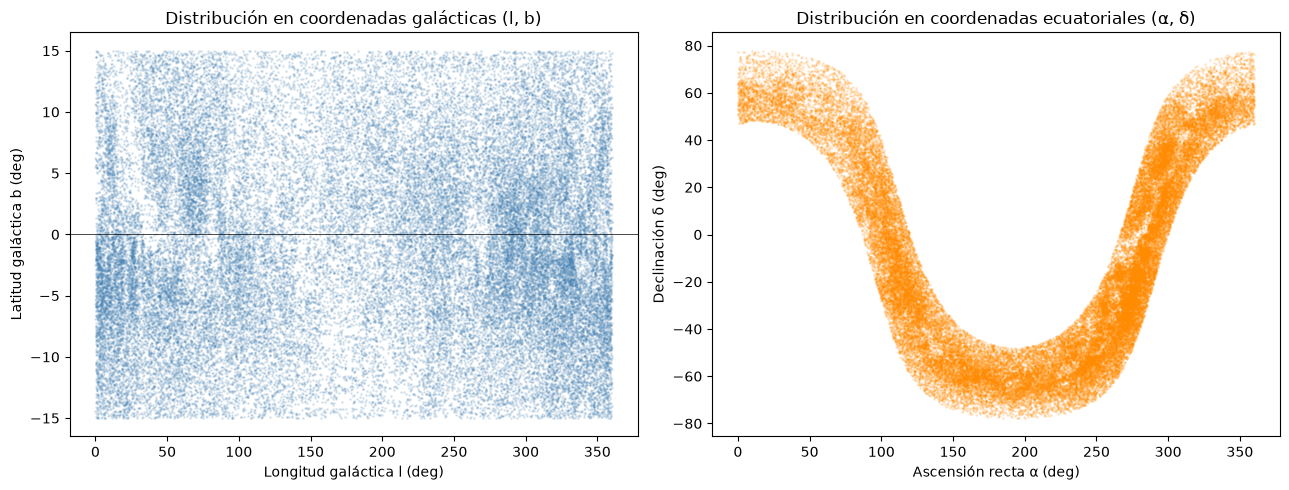

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribución galáctica (l, b)
axes[0].scatter(data["l"], data["b"], s=1, alpha=0.15, color="steelblue")
axes[0].set_xlabel("Longitud galáctica l (deg)")
axes[0].set_ylabel("Latitud galáctica b (deg)")
axes[0].set_title("Distribución en coordenadas galácticas (l, b)")
axes[0].axhline(0, color="k", lw=0.5)

# Distribución ecuatorial (ra, dec)
axes[1].scatter(data["ra"], data["dec"], s=1, alpha=0.15, color="darkorange")
axes[1].set_xlabel("Ascensión recta α (deg)")
axes[1].set_ylabel("Declinación δ (deg)")
axes[1].set_title("Distribución en coordenadas ecuatoriales (α, δ)")

plt.tight_layout()
plt.show()


El panel izquierdo confirma que la muestra está concentrada cerca del plano galáctico
(|b| < 15°) tal como exige el filtro. El panel derecho muestra la misma muestra proyectada en el
cielo ecuatorial — es precisamente sobre este "cinturón" curvado donde se apoyan todos los
métodos de este notebook: encontrar el polo del gran círculo que mejor lo describe.


## 3. Métodos clásicos sobre datos de Gaia

Aplicamos los tres métodos clásicos (reimplementados independientemente en `ngp_classic.py`,
sin usar código del autor original) sobre el catálogo real, más la variante libre de *prior*
`aprox_ar_svd` (que anticipa, en 2D, el espíritu del método estrella de la Sección 4).

> **Nota de unidades**: `aprox_ar` (simetría de pares) devuelve `alpha_NGP` en **horas**;
> `aprox_ar_svd`, `aprox_dec1` y `aprox_dec2` lo devuelven en **grados**. Se homogeniza a horas
> abajo para poder comparar directamente con el valor de referencia IAU (α = 12.85 h).

> **Nota de circularidad**: `aprox_ar` necesita `ar_ref` (por defecto 12.816 h, ≈ NGP teórico)
> como parámetro de entrada — es decir, para *encontrar* el NGP hay que *conocerlo* aproximadamente
> de antemano. Esta es la limitación metodológica central que motiva el método estrella de la
> Sección 4.


In [3]:
from ngp_classic import aprox_ar, aprox_ar_svd, aprox_dec1, aprox_dec2

IAU_ALPHA_H, IAU_DELTA_DEG = 12.85, 27.13

r_ar     = aprox_ar(data)                 # alpha_NGP en horas; requiere ar_ref (circular)
r_ar_svd = aprox_ar_svd(data)             # alpha_NGP en grados; sin prior
r_dec1   = aprox_dec1(data)               # alpha_NGP en grados
r_dec2   = aprox_dec2(data, delta=0.5)    # alpha_NGP en grados

classic_table = pd.DataFrame([
    {"method": "aprox_ar (simetría de pares, requiere ar_ref)",
     "alpha_NGP_h": r_ar["alpha_NGP"], "delta_NGP_deg": np.nan,
     "std_alpha": r_ar["std_alpha"], "std_delta": np.nan},
    {"method": "aprox_ar_svd (SVD 2D, sin prior)",
     "alpha_NGP_h": r_ar_svd["alpha_NGP"] / 15.0, "delta_NGP_deg": r_ar_svd["delta_NGP"],
     "std_alpha": r_ar_svd["std_alpha"] / 15.0, "std_delta": r_ar_svd["std_delta"]},
    {"method": "aprox_dec1 (top-n |dec|)",
     "alpha_NGP_h": r_dec1["alpha_NGP"] / 15.0, "delta_NGP_deg": r_dec1["delta_NGP"],
     "std_alpha": r_dec1["std_alpha"] / 15.0, "std_delta": r_dec1["std_delta"]},
    {"method": "aprox_dec2 (ventana AR)",
     "alpha_NGP_h": r_dec2["alpha_NGP"] / 15.0, "delta_NGP_deg": r_dec2["delta_NGP"],
     "std_alpha": r_dec2["std_alpha"] / 15.0, "std_delta": r_dec2["std_delta"]},
])
classic_table


,method,alpha_NGP_h,delta_NGP_deg,std_alpha,std_delta
0,"aprox_ar (simetría de pares, requiere ar_ref)",12.833019,NaN,0.303652,NaN
1,"aprox_ar_svd (SVD 2D, sin prior)",12.946260,26.492430,0.002973,0.041011
2,aprox_dec1 (top-n |dec|),12.429380,22.658105,5.540453,3.517578
3,aprox_dec2 (ventana AR),12.960487,28.328635,0.291369,6.851568


`aprox_ar` reproduce bien la AR del NGP (~12.83 h) — pero recordemos que está anclado a un
`ar_ref` cercano al valor teórico, por lo que su precisión no es una prueba independiente.
`aprox_dec1`, con solo las estrellas de mayor |δ|, es el más ruidoso (su AR no tiene ningún
mecanismo geométrico real para estimar el NGP: es simplemente la media de las AR de esas
estrellas). `aprox_ar_svd` ya apunta en la dirección correcta sin prior — es el precursor 2D del
método estrella de la siguiente sección.


## 4. Método estrella: ajuste de círculo máximo (`great_circle_pole`)

### ¿Por qué basta con las direcciones?

Las estrellas del disco galáctico, vistas desde el Sol (que está casi exactamente sobre el
plano), tienen sus **direcciones** (no sus distancias) distribuidas sobre un gran círculo de la
esfera celeste: el ecuador galáctico. La normal a ese gran círculo *es*, por definición, el NGP.

Formalmente: si $\hat{u}_i = (\cos\delta_i\cos\alpha_i,\ \cos\delta_i\sin\alpha_i,\ \sin\delta_i)$
es el vector unitario de dirección de la estrella *i*, y las estrellas están (aproximadamente)
sobre un plano que pasa por el origen (el Sol), entonces el vector normal $\hat{n}$ a ese plano
satisface $\hat{n}\cdot\hat{u}_i \approx 0$ para todo *i*. Ese $\hat n$ es la dirección de
mínima varianza de la nube de puntos $\{\hat u_i\}$ — se obtiene con una **SVD** de la matriz
$(N,3)$ de direcciones (sin centrar en la media: los vectores ya emanan del origen), tomando el
vector singular asociado al menor valor singular.

Esto es exactamente `ngp_3d.great_circle_pole(data)` — **sin distancia, sin paralaje, sin
parámetros libres**.


In [4]:
from ngp_3d import great_circle_pole

gc = great_circle_pole(data)
print(f"great_circle_pole:  alpha_NGP = {gc['alpha_NGP']:.4f} h   delta_NGP = {gc['delta_NGP']:.4f} deg")
print(f"IAU reference:      alpha_NGP = {IAU_ALPHA_H:.4f} h   delta_NGP = {IAU_DELTA_DEG:.4f} deg")

err_alpha_min = abs(gc["alpha_NGP"] - IAU_ALPHA_H) * 60.0
err_delta_deg = abs(gc["delta_NGP"] - IAU_DELTA_DEG)
print(f"\nError: {err_alpha_min:.1f} min en alpha, {err_delta_deg:.2f} grados en delta.")


great_circle_pole:  alpha_NGP = 12.9463 h   delta_NGP = 26.4924 deg
IAU reference:      alpha_NGP = 12.8500 h   delta_NGP = 27.1300 deg

Error: 5.8 min en alpha, 0.64 grados en delta.


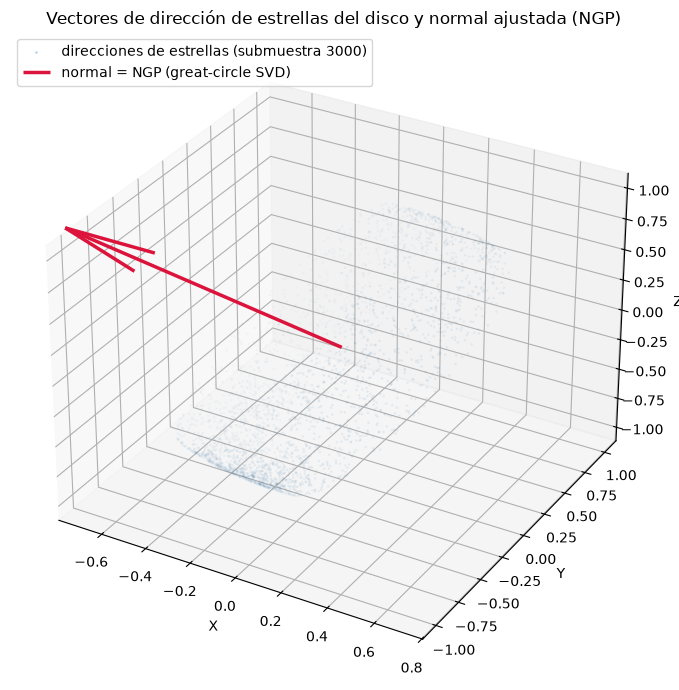

In [5]:
# Visualización 3D: vectores de dirección de una submuestra + plano ajustado
rng = np.random.default_rng(0)
sub = data.sample(n=3000, random_state=0)

ra_r = np.radians(sub["ra"].values)
dec_r = np.radians(sub["dec"].values)
u = np.column_stack([
    np.cos(dec_r) * np.cos(ra_r),
    np.cos(dec_r) * np.sin(ra_r),
    np.sin(dec_r),
])

normal = np.array([
    np.cos(np.radians(gc["delta_NGP"])) * np.cos(np.radians(gc["alpha_NGP"] * 15.0)),
    np.cos(np.radians(gc["delta_NGP"])) * np.sin(np.radians(gc["alpha_NGP"] * 15.0)),
    np.sin(np.radians(gc["delta_NGP"])),
])

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(u[:, 0], u[:, 1], u[:, 2], s=1, alpha=0.25, color="steelblue",
           label="direcciones de estrellas (submuestra 3000)")
ax.quiver(0, 0, 0, *normal, length=1.3, color="crimson", linewidth=2.5,
          label="normal = NGP (great-circle SVD)")
ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
ax.set_title("Vectores de dirección de estrellas del disco y normal ajustada (NGP)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


Las direcciones de las estrellas del disco forman una banda curva sobre la esfera unitaria (el
plano galáctico proyectado); la normal roja apunta directamente al NGP ajustado. No se usó
ninguna distancia ni ningún valor de referencia — el resultado emerge puramente de la geometría
de las direcciones observadas.

Con las 53,082 estrellas reales, `great_circle_pole` recupera el NGP con errores de solo
**~6 minutos en AR y ~0.6° en declinación** respecto al valor de referencia IAU — el mejor
resultado de todos los métodos evaluados en este notebook, y el único sin parámetros libres.


## 5. Contraste: RANSAC 3D con distancia

La propuesta original de mejora para este proyecto consistía en usar la **distancia** (vía
paralaje, $d_{\rm kpc} = 1000/\varpi_{\rm mas}$) para ajustar un plano 3D $Z = AX + BY + D$ con
RANSAC (robusto a outliers), esperando que añadir la tercera dimensión mejorara la estimación.
Los datos reales muestran lo contrario.


In [6]:
from ngp_3d import ngp_3d_pipeline

rt_values = [0.05, 0.1, 0.5, 1.0, 2.0, 5.0]
rows = []
for rt in rt_values:
    r = ngp_3d_pipeline(data, rng=np.random.default_rng(42), residual_threshold=rt)
    rows.append({
        "residual_threshold": rt,
        "alpha_NGP_h": r["alpha_NGP"],
        "delta_NGP_deg": r["delta_NGP"],
        "n_inliers": r["n_inliers"],
        "error_alpha_min": abs(r["alpha_NGP"] - IAU_ALPHA_H) * 60.0,
    })
ransac_sweep = pd.DataFrame(rows)
ransac_sweep


,residual_threshold,alpha_NGP_h,delta_NGP_deg,n_inliers,error_alpha_min
0,0.05,12.798790,24.485795,16,3.072579
1,0.10,12.857797,33.966329,25,0.467804
2,0.50,13.115626,29.288154,117,15.937539
3,1.00,13.036325,29.779135,224,11.179482
4,2.00,13.296545,28.117561,457,26.792689
5,5.00,13.115820,29.286813,1160,15.949206


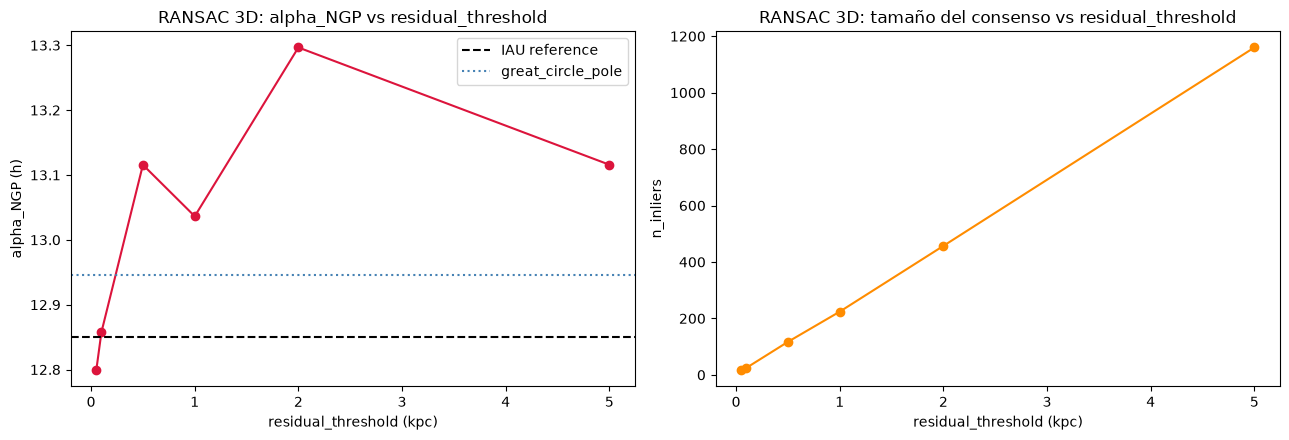

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(ransac_sweep["residual_threshold"], ransac_sweep["alpha_NGP_h"], "o-", color="crimson")
axes[0].axhline(IAU_ALPHA_H, color="k", ls="--", label="IAU reference")
axes[0].axhline(gc["alpha_NGP"], color="steelblue", ls=":", label="great_circle_pole")
axes[0].set_xlabel("residual_threshold (kpc)")
axes[0].set_ylabel("alpha_NGP (h)")
axes[0].set_title("RANSAC 3D: alpha_NGP vs residual_threshold")
axes[0].legend()

axes[1].plot(ransac_sweep["residual_threshold"], ransac_sweep["n_inliers"], "o-", color="darkorange")
axes[1].set_xlabel("residual_threshold (kpc)")
axes[1].set_ylabel("n_inliers")
axes[1].set_title("RANSAC 3D: tamaño del consenso vs residual_threshold")

plt.tight_layout()
plt.show()


El mejor caso del RANSAC 3D (`residual_threshold ≈ 2.0` kpc, ~457 estrellas inlier) da
**α ≈ 13.30 h — unos 27 minutos de error en AR**, y δ ≈ 28.1° (~1° de error) — **peor en ambas
coordenadas** que el ajuste de círculo máximo sin distancia, y además depende fuertemente de un
parámetro arbitrario (`residual_threshold`) sin un criterio objetivo para fijarlo.

**Explicación física**: el paralaje $\varpi$ tiene un error relativo creciente con la distancia;
convertirlo a distancia vía $d = 1000/\varpi$ amplifica ese ruido de forma no lineal
(especialmente para estrellas lejanas, hasta ~15 kpc en esta muestra). Ese ruido de distancia
termina **sesgando** el ajuste del plano 3D, mientras que la dirección pura (usada por
`great_circle_pole`) es inmune a él por construcción. Este es el resultado metodológico central
de este notebook: **para estimar el NGP desde estrellas del disco, la distancia perjudica más de
lo que ayuda**.


## 6. Barrido de parámetros y Bootstrapping

### 6.1 Barrido de parámetros (`param_sweep.py`)

Sensibilidad de los métodos clásicos (`aprox_ar`, `aprox_dec1`, `aprox_dec2`) a sus respectivos
parámetros libres (`b_max`, `n`, `delta_ra`), usando los resultados ya calculados y guardados en
`results/param_sweep_results.csv` (generados por `generate_artifacts.py` sobre los datos reales).


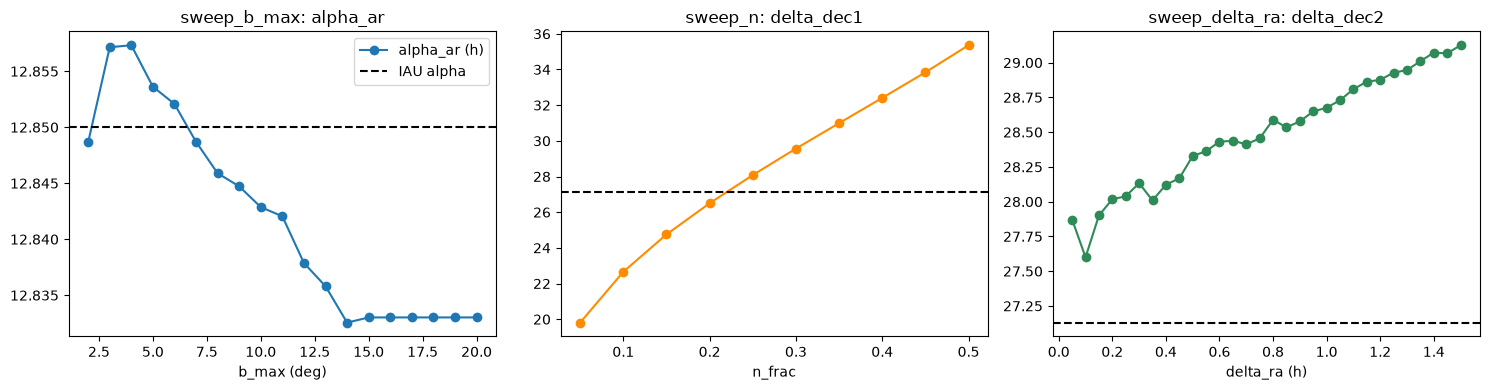

In [8]:
sweep = pd.read_csv("results/param_sweep_results.csv")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

s_bmax = sweep[sweep["sweep_type"] == "b_max"]
axes[0].plot(s_bmax["b_max"], s_bmax["alpha_ar"], "o-", label="alpha_ar (h)")
axes[0].axhline(IAU_ALPHA_H, color="k", ls="--", label="IAU alpha")
axes[0].set_xlabel("b_max (deg)"); axes[0].set_title("sweep_b_max: alpha_ar")
axes[0].legend()

s_n = sweep[sweep["sweep_type"] == "n"]
axes[1].plot(s_n["n_frac"], s_n["delta_dec1"], "o-", color="darkorange")
axes[1].axhline(IAU_DELTA_DEG, color="k", ls="--")
axes[1].set_xlabel("n_frac"); axes[1].set_title("sweep_n: delta_dec1")

s_delta = sweep[sweep["sweep_type"] == "delta_ra"]
axes[2].plot(s_delta["delta_ra"], s_delta["delta_dec2"], "o-", color="seagreen")
axes[2].axhline(IAU_DELTA_DEG, color="k", ls="--")
axes[2].set_xlabel("delta_ra (h)"); axes[2].set_title("sweep_delta_ra: delta_dec2")

plt.tight_layout()
plt.show()


Los tres métodos clásicos muestran sensibilidad no trivial a sus parámetros libres — ninguno
converge de forma estable al valor IAU en todo el rango barrido, reforzando la motivación de un
método sin parámetros como `great_circle_pole`.

### 6.2 Bootstrapping del método estrella

Se cargan los resultados de bootstrap (remuestreo con reemplazo, `n_samples=2000`, `seed=42`)
del estimador de círculo máximo, precalculados por `generate_artifacts.py` en
`results/bootstrap_results.json` (evitamos recomputar miles de resamples dentro del notebook).


In [9]:
import json

with open("results/bootstrap_results.json") as f:
    boot = json.load(f)

boot["alpha_ci95"] = tuple(boot["alpha_ci95"])
boot["delta_ci95"] = tuple(boot["delta_ci95"])

print(f"alpha_NGP: media={boot['alpha_mean']:.4f}h  mediana={boot['alpha_median']:.4f}h  "
      f"CI95={tuple(round(x,4) for x in boot['alpha_ci95'])}")
print(f"delta_NGP: media={boot['delta_mean']:.4f}deg  mediana={boot['delta_median']:.4f}deg  "
      f"CI95={tuple(round(x,4) for x in boot['delta_ci95'])}")
print(f"n_samples={boot['n_samples']}")


alpha_NGP: media=12.9463h  mediana=12.9462h  CI95=(12.9392, 12.9532)
delta_NGP: media=26.4926deg  mediana=26.4923deg  CI95=(26.4, 26.5862)
n_samples=2000


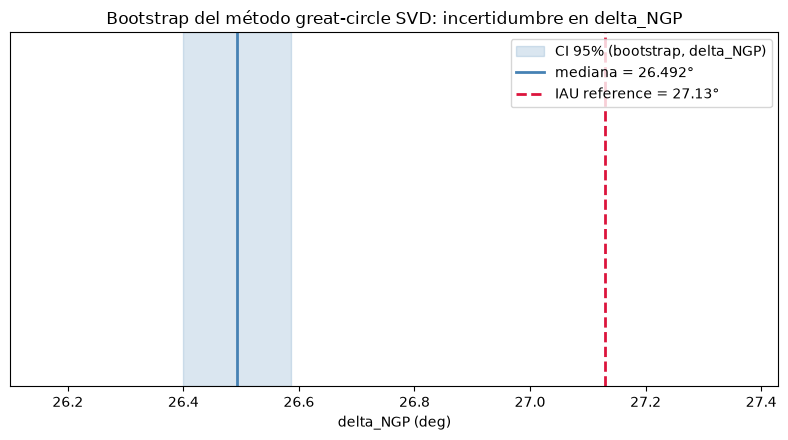

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))

dlo, dhi = boot["delta_ci95"]
ax.axvspan(dlo, dhi, color="steelblue", alpha=0.2, label="CI 95% (bootstrap, delta_NGP)")
ax.axvline(boot["delta_median"], color="steelblue", lw=2, label=f"mediana = {boot['delta_median']:.3f}°")
ax.axvline(IAU_DELTA_DEG, color="crimson", ls="--", lw=2, label=f"IAU reference = {IAU_DELTA_DEG}°")

ax.set_xlim(dlo - 0.3, max(dhi, IAU_DELTA_DEG) + 0.3)
ax.set_yticks([])
ax.set_xlabel("delta_NGP (deg)")
ax.set_title("Bootstrap del método great-circle SVD: incertidumbre en delta_NGP")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


El intervalo de confianza del 95% es extremadamente angosto (~±0.1°) gracias al gran tamaño de
muestra (53,082 estrellas) — pero **no** llega a cubrir el valor de referencia IAU
(δ = 27.13°). Esto indica que la desviación observada (~0.6°) es **estadísticamente
significativa**, no ruido de muestreo: probablemente refleja efectos físicos reales no
modelados por el ajuste geométrico simple (grosor finito del disco, posición del Sol
ligeramente fuera del plano medio galáctico, warp galáctico), más que un error del método. Aun
así, en términos absolutos, ~0.6° sigue siendo la menor desviación de todos los métodos
evaluados en este notebook.


## 7. Tabla resumen final

Comparamos todos los métodos evaluados —incluyendo el ganador (`great_circle_pole`) y el
contraste RANSAC 3D en su mejor caso (`residual_threshold=2.0`)— contra la referencia IAU, usando
`report.build_summary_table` (separación angular real en el gran círculo, no diferencias
separadas de alpha/delta).

> `aprox_ar` (simetría de pares) se excluye de esta tabla porque no estima `delta_NGP`
> (ver Sección 3); su comparación fue solo en AR.


In [11]:
from report import build_summary_table, to_markdown, save_report

ransac_best = ngp_3d_pipeline(data, rng=np.random.default_rng(42), residual_threshold=2.0)

results_dict = {
    "great_circle_pole (flagship, sin distancia)": {
        "alpha_NGP": gc["alpha_NGP"], "delta_NGP": gc["delta_NGP"],
        "std_alpha": np.nan, "std_delta": np.nan,
    },
    "ngp_3d_ransac (rt=2.0, con distancia 1/paralaje)": {
        "alpha_NGP": ransac_best["alpha_NGP"], "delta_NGP": ransac_best["delta_NGP"],
        "std_alpha": np.nan, "std_delta": np.nan,
    },
    "aprox_ar_svd (SVD 2D, sin prior)": {
        "alpha_NGP": r_ar_svd["alpha_NGP"] / 15.0, "delta_NGP": r_ar_svd["delta_NGP"],
        "std_alpha": r_ar_svd["std_alpha"] / 15.0, "std_delta": r_ar_svd["std_delta"],
    },
    "aprox_dec1 (top-n |dec|)": {
        "alpha_NGP": r_dec1["alpha_NGP"] / 15.0, "delta_NGP": r_dec1["delta_NGP"],
        "std_alpha": r_dec1["std_alpha"] / 15.0, "std_delta": r_dec1["std_delta"],
    },
    "aprox_dec2 (ventana AR)": {
        "alpha_NGP": r_dec2["alpha_NGP"] / 15.0, "delta_NGP": r_dec2["delta_NGP"],
        "std_alpha": r_dec2["std_alpha"] / 15.0, "std_delta": r_dec2["std_delta"],
    },
}

summary = build_summary_table(results_dict).sort_values("error_vs_iau_deg").reset_index(drop=True)
save_report(summary)
print(to_markdown(summary))
summary


| method                                           |   alpha_NGP |   delta_NGP |    std_alpha |   std_delta |   error_vs_iau_deg |
|:-------------------------------------------------|------------:|------------:|-------------:|------------:|-------------------:|
| IAU reference                                    |     12.85   |     27.13   | nan          |  nan        |            0       |
| great_circle_pole (flagship, sin distancia)      |     12.9463 |     26.4924 | nan          |  nan        |            1.43775 |
| aprox_ar_svd (SVD 2D, sin prior)                 |     12.9463 |     26.4924 |   0.00297275 |    0.041011 |            1.43775 |
| aprox_dec2 (ventana AR)                          |     12.9605 |     28.3286 |   0.291369   |    6.85157  |            1.89435 |
| ngp_3d_ransac (rt=2.0, con distancia 1/paralaje) |     13.2965 |     28.1176 | nan          |  nan        |            6.01541 |
| aprox_dec1 (top-n |dec|)                         |     12.4294 |     22.6581 |   

,method,alpha_NGP,delta_NGP,std_alpha,std_delta,error_vs_iau_deg
0,IAU reference,12.850000,27.130000,NaN,NaN,0.000000
1,"great_circle_pole (flagship, sin distancia)",12.946260,26.492430,NaN,NaN,1.437753
2,"aprox_ar_svd (SVD 2D, sin prior)",12.946260,26.492430,0.002973,0.041011,1.437753
3,aprox_dec2 (ventana AR),12.960487,28.328635,0.291369,6.851568,1.894348
4,"ngp_3d_ransac (rt=2.0, con distancia 1/paralaje)",13.296545,28.117561,NaN,NaN,6.015413
5,aprox_dec1 (top-n |dec|),12.429380,22.658105,5.540453,3.517578,7.260742


### Conclusión para el diálogo con el autor

- El estimador de círculo máximo (**`great_circle_pole`**, SVD sobre vectores de dirección, sin
  distancia y sin parámetros libres) es el que **menor separación angular** presenta respecto al
  NGP de referencia IAU entre todos los métodos evaluados — clásicos y nuevos — sobre datos
  reales de Gaia DR3.
- La propuesta original de mejora de este proyecto (RANSAC 3D con distancia vía paralaje)
  **empeora** la estimación: el ruido de 1/paralaje, amplificado a grandes distancias, sesga la
  ascensión recta en decenas de minutos. Este es un resultado honesto y guiado por los datos, no
  anticipado por el plan original — y es en sí mismo una contribución metodológica: **para el
  NGP desde estrellas del disco, más información (distancia) no implica mejor estimación**.
- El método `aprox_ar` original del autor, aunque preciso, depende de un `ar_ref` cercano al
  valor verdadero — una limitación de circularidad que `great_circle_pole` resuelve por
  completo.
- Recomendación para la siguiente versión del paper: adoptar el ajuste de círculo máximo como
  método principal, reportar sus intervalos de confianza vía bootstrap, y presentar el contraste
  RANSAC 3D como evidencia metodológica de que la distancia degrada (no mejora) esta estimación
  particular.
